In [11]:
#save model
joblib.dump(
    model,
    "../models/random_forest_model.pkl"
)

['../models/random_forest_model.pkl']

In [10]:
#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
5,shipment_value,0.239839
0,shipment_quantity,0.233033
3,stock_quantity,0.180073
1,unit_price,0.174525
6,supplier_avg_delay,0.058144
4,rating,0.057283
2,lead_time,0.057102


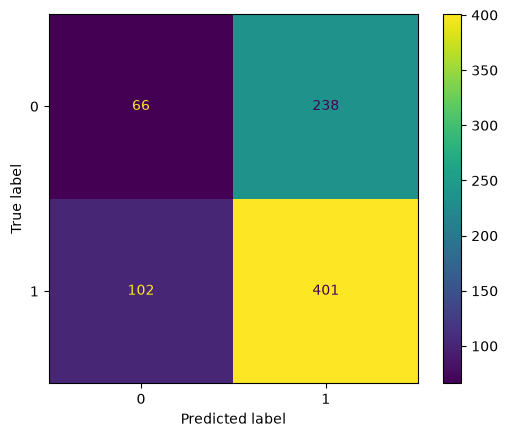

In [9]:
#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.show()

In [8]:
#Classification Report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.39      0.22      0.28       304
           1       0.63      0.80      0.70       503

    accuracy                           0.58       807
   macro avg       0.51      0.51      0.49       807
weighted avg       0.54      0.58      0.54       807



In [7]:
#Accuracy
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.5786864931846345


In [6]:
#predicition
predictions = model.predict(X_test)

In [5]:
#Train Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [4]:
#Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [3]:
#Select Features
features = [
    "shipment_quantity",
    "unit_price",
    "lead_time",
    "stock_quantity",
    "rating",
    "shipment_value",
    "supplier_avg_delay"
]

X = df[features]

y = df["is_delayed"]

In [2]:
#Load Dataset
df = pd.read_csv("../data/feature_engineered_supply_chain.csv")

df.head()

,shipment_id,supplier_id,product_id,shipment_date,expected_arrival,actual_arrival,shipment_quantity,shipment_status,product_name,category,...,shipment_month,shipment_year,shipment_quarter,shipment_weekday,is_delayed,delay_category,high_severity,large_shipment,inventory_status,shipment_value
0,1,6,29,2025-06-03,2025-06-07,2025-06-12,16,In Transit,Architecto Product,Furniture,...,June,2025,2,Tuesday,1,Major Delay,0,0,High,66932.96
1,2,7,84,2025-06-16,2025-06-26,2025-06-24,106,Delayed,Ab Product,Clothing,...,June,2025,2,Monday,0,On Time,0,0,Low,117507.36
2,3,9,119,2026-03-17,2026-03-23,2026-03-24,325,In Transit,Maxime Product,Furniture,...,March,2026,1,Tuesday,1,Minor Delay,1,1,High,1558355.50
3,4,5,140,2025-04-20,2025-04-23,2025-04-28,419,Cancelled,Recusandae Product,Groceries,...,April,2025,2,Sunday,1,Major Delay,0,1,High,1133625.45
4,5,18,56,2025-11-20,2025-11-23,2025-11-28,136,Delayed,Error Product,Electronics,...,November,2025,4,Thursday,1,Major Delay,0,0,High,45312.48


In [1]:
# Day 10: Random Forest Model
## SupplyPrescript - Shipment Delay Prediction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Matplotlib is building the font cache; this may take a moment.
